**1.Постановка задачи и анализ предметной области.**

Бизнес-задача заключается в разработке модели машинного обучения для автоматизированной оценки стоимости единицы площади объектов недвижимости. На сегодняшний день оценка недвижимости в риелторских компаниях, банках и оценочных агентствах часто проводится вручную на основе субъективного опыта экспертов, что занимает много времени (от нескольких часов до нескольких дней) и приводит к разногласиям между сторонами сделки из-за отсутствия единого стандарта оценки. Целью является создание модели, которая по шести характеристикам объекта (возраст дома, расстояние до метро, количество магазинов в пешей доступности, географические координаты и дата сделки) будет предсказывать цену за единицу площади с точностью, достаточной для практического использования. Ожидаемый эффект от внедрения такой модели включает сокращение времени оценки объекта с нескольких часов до нескольких секунд, исключение субъективного фактора и разногласий между сторонами, стандартизацию процесса ценообразования, а также возможность автоматизированной предварительной оценки большого количества объектов. Ожидается сокращение времени оценки одного объекта с 2-3 часов до секунд, увеличение количества обрабатываемых заявок в день на одного оценщика, снижение процента ошибочных оценок, экономия 2 млн руб/год на зарплате оценщиков при объёме 1000 объектов/месяц (оценка экономии примерная, так как изначально количество компаний, которые внедрят эту ситстему не точное).

Предметной областю является рынок жилой недвижимости Тайбэя (Тайвань). Данные для исследования взяты из открытого датасета UCI Real Estate Valuation, содержащего 414 реальных записей о сделках купли-продажи за 2012-2013 годы. Цена недвижимости в этом регионе критически зависит от нескольких ключевых факторов. Расстояние до ближайшей станции метро имеет сильное отрицательное влияние, причём зависимость носит нелинейный характер: сокращение дистанции с 2000 до 500 метров значительно повышает цену, тогда как дальнейшее сокращение с 200 до 50 метров даёт гораздо меньший эффект. Возраст дома демонстрирует слабую отрицательную связь, но с важной аномалией: дома, построенные в 1990-е годы, стоят дешевле, чем дома советской постройки, что связано с экономическим кризисом в регионе в тот период. Количество магазинов в пешей доступности влияет положительно, но также нелинейно: на графике зависимости видны локальные падения цены при трёх и семи магазинах, что требует дополнительного анализа. Географические координаты (широта и долгота) определяют престижность конкретного района: северные и восточные районы Тайбэя в среднем дороже. Дата сделки учитывается из-за возможных сезонных и трендовых колебаний рынка, хотя её влияние в данном наборе данных оказалось слабым.

Применение методов машинного обучения для решения данной задачи обусловлено сложностью и нелинейностью зависимостей между ценой недвижимости и её характеристиками. Традиционные аналитические подходы не способны уловить эффект насыщения (как в случае с расстоянием до метро) или локальные аномалии (как в случае с количеством магазинов или возрастом домов 1990-х). Кроме того, качество строительства домов в разные исторические эпохи создаёт дополнительные нелинейные эффекты, которые невозможно описать простой линейной формулой. Методы на основе деревьев, такие как случайный лес и градиентный бустинг (CatBoost), автоматически выявляют такие нелинейные пороги и взаимодействия между признаками, обеспечивая более точные и объективные предсказания по сравнению с экспертными оценками или простой линейной регрессией.

Типом задачи в данном проекте является регрессия, так как мы предсказываем непрерывную числовую величину, а именно стоимость единицы площади недвижимости в тысячах новых тайваньских долларов за Ping (где один Ping равен 3.3 квадратным метрам). В отличие от задачи классификации, где нужно отнести объект к одному из классов, здесь результат представляет собой конкретное число, которое может принимать любое значение в диапазоне от 10 до 80 тысяч NTD за Ping. Для оценки качества модели выбраны три метрики. Коэффициент детерминации R² показывает, насколько хорошо модель объясняет изменчивость цен, и чем ближе его значение к единице, тем лучше. Метрика RMSE (корень из среднеквадратичной ошибки) измеряет среднюю ошибку предсказания и штрафует большие ошибки за счёт возведения в квадрат, что критически важно для дорогой недвижимости, где крупная ошибка недопустима. Метрика MAE (средняя абсолютная ошибка) показывает среднюю ошибку в единицах целевой переменной (тысячах NTD за Ping) и является более устойчивой к выбросам, что даёт понятную бизнесу интерпретацию. Совместное использование этих трёх метрик позволяет оценить модель с разных сторон: объясняющую способность, чувствительность к крупным ошибкам и среднюю абсолютную ошибку в деньгах.

R² выбран, потому что показывает долю объяснённой дисперсии — это понятная бизнесу метрика.
RMSE выбран, потому что штрафует крупные ошибки, что критично для дорогой недвижимости.
MAE выбран, потому что интерпретируется в деньгах (тыс. NTD/Ping) и устойчив к выбросам.
MAPE не выбран, потому что целевая переменная содержит нулевые и близкие к нулю значения.

Ограничения и допущения модели следующие. Модель обучена на данных только одного района Тайбэя, поэтому её применение за пределами этого района требует дообучения. Модель не учитывает такие важные факторы, как этаж, наличие ремонта, вид из окна или парковки, поэтому часть ошибки предсказания может быть связана именно с отсутствием этих признаков. Мы допускаем, что зависимость цены от признаков остаётся стабильной во времени (стационарность), а выбросы в данных являются ошибками сбора, а не реальными рыночными аномалиями. При внедрении модели необходимо учитывать следующие риски. При использовании модели на новых данных нужно убедиться, что они собраны по той же методологии. Данные взяты из открытых источников, что может создавать смещение выборки в сторону определённых типов объектов. Автоматическая оценка не должна полностью заменять эксперта, особенно в спорных случаях модель следует рассматривать как инструмент поддержки принятия решений. Кроме того, при изменении рыночной ситуации (резкий рост или падение рынка) модель требует переобучения на актуальных данных, так как её допущение о стационарности перестаёт выполняться.

**2.Сбор, подготовка и анализ данных (EDA).**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from math import sqrt
from sklearn.model_selection import GridSearchCV
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from matplotlib.patches import FancyBboxPatch
import joblib
from google.colab import files
import warnings
from scipy import stats
!pip install catboost -q
from catboost import CatBoostRegressor
import shap
!pip install phik -q
import phik
from sklearn.neighbors import LocalOutlierFactor
!pip install mlflow -q
import mlflow
from sklearn.model_selection import TimeSeriesSplit
from math import radians, sin, cos, sqrt, atan2
!pip install ImbalancedLearningRegression -q
import ImbalancedLearningRegression as iblr
!pip install smogn -q
import smogn
warnings.filterwarnings('ignore')
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/IT академия/итоговое задание/data.csv')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 11.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 55.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2

In [ ]:
df.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


первичная очистка. Проверяем типы данных,  NaN-значения, Проверка на наличие дубликатов во всех колонках,  Удаляем дубликаты и перетираем индексы, Ищем пустые строки

In [ ]:
df.info()
df.isna().sum()
df[df.duplicated()]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X1 transaction date                     414 non-null    float64
 1   X2 house age                            414 non-null    float64
 2   X3 distance to the nearest MRT station  414 non-null    float64
 3   X4 number of convenience stores         414 non-null    int64  
 4   X5 latitude                             414 non-null    float64
 5   X6 longitude                            414 non-null    float64
 6   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 22.8 KB


,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area


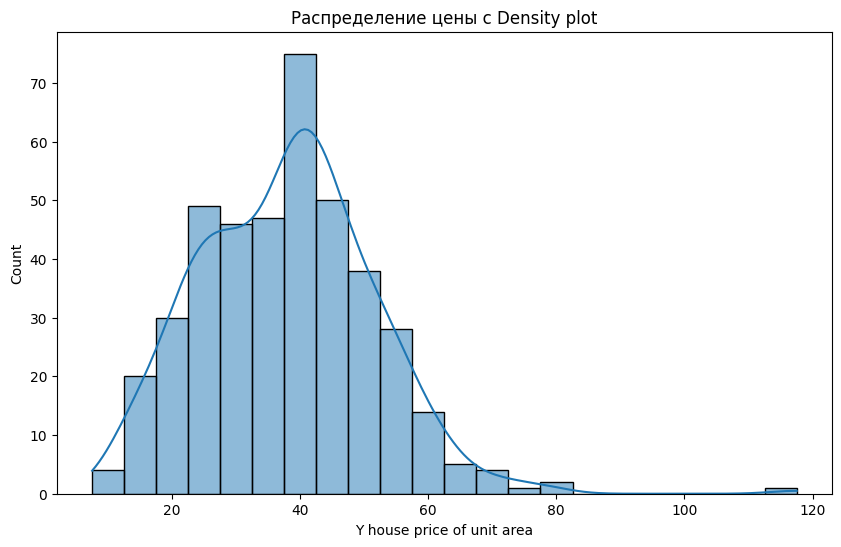

In [ ]:
fig = px.histogram(df, x="X4 number of convenience stores")
fig.show()
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="Y house price of unit area", kde=True)
plt.title('Распределение цены с Density plot')
plt.show()
fig = px.box(df, y="Y house price of unit area")
fig.show()

 Наибольшее количество объектов недвижимости расположено в районах с 5 магазинами в пешей доступности (около 70 объектов). Много объектов с 3, 4, 6 и 7 магазинами. Объекты с 0-1 магазином появоляются часто, а более 8-10 магазинами встречаются значительно реже. Это говорит о том, что исследуемый район имеет преимущественно среднюю концентрацию торговых точек, а районы с очень малым или очень большим количеством магазинов представлены слабо.

Распределение цены за единицу площади асимметрично с длинным правым хвостом. Основная масса объектов находится в диапазоне от 25 до 50 тысяч NTD за Ping, с пиком в районе 35-40 тысяч. Присутствуют отдельные дорогие объекты с ценой выше 60-70 тысяч, что характерно для рынка недвижимости, где есть как доступные, так и премиальные объекты. Левая граница распределения находится около 10-15 тысяч.

На boxplot отчётливо видны три точки выше верхнего предела, расположенные в районе 70-120 тысяч NTD/Ping. Это означает, что в данных присутствуют три объекта с аномально высокой ценой по сравнению с основным массивом данных. Такие выбросы могут искажать обучение модели, поэтому на следующем этапе они будут обработаны.

Вместо грубой замены выбросов на медиану используем преобразование Бокса-Кокса.


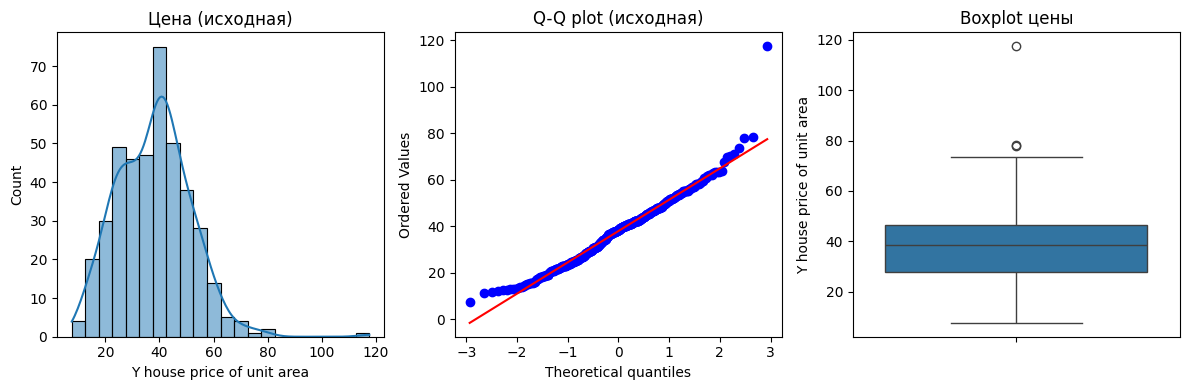

Асимметрия до: 0.5999

Оптимальная лямбда: 0.5894


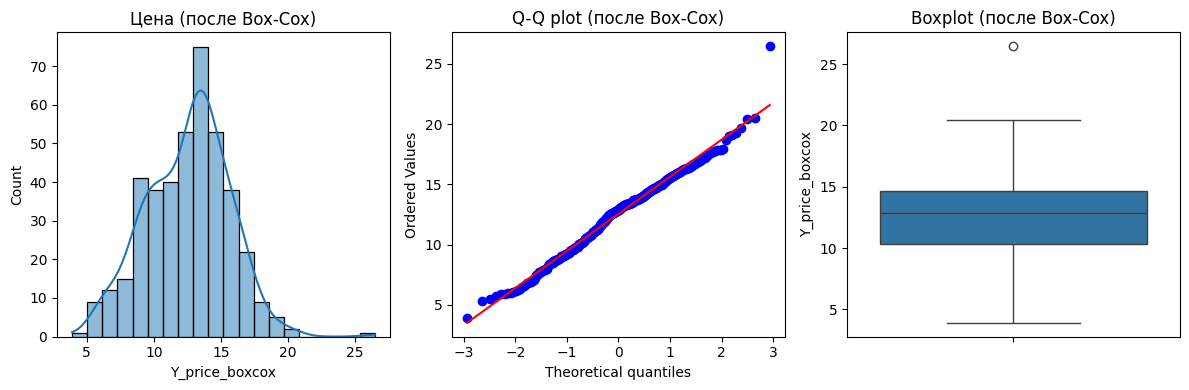

Асимметрия после: 0.0095


In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.histplot(df['Y house price of unit area'], kde=True)
plt.title('Цена (исходная)')
plt.subplot(1, 3, 2)
stats.probplot(df['Y house price of unit area'], dist="norm", plot=plt)
plt.title('Q-Q plot (исходная)')
plt.subplot(1, 3, 3)
sns.boxplot(y=df['Y house price of unit area'])
plt.title('Boxplot цены')
plt.tight_layout()
plt.show()
print(f"Асимметрия до: {df['Y house price of unit area'].skew():.4f}")
df['Y_price_boxcox'], lambda_opt = stats.boxcox(df['Y house price of unit area'])
print(f"\nОптимальная лямбда: {lambda_opt:.4f}")
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.histplot(df['Y_price_boxcox'], kde=True)
plt.title('Цена (после Box-Cox)')
plt.subplot(1, 3, 2)
stats.probplot(df['Y_price_boxcox'], dist="norm", plot=plt)
plt.title('Q-Q plot (после Box-Cox)')
plt.subplot(1, 3, 3)
sns.boxplot(y=df['Y_price_boxcox'])
plt.title('Boxplot (после Box-Cox)')
plt.tight_layout()
plt.show()
print(f"Асимметрия после: {df['Y_price_boxcox'].skew():.4f}")
df['Y house price of unit area'] = df['Y_price_boxcox']
df = df.drop('Y_price_boxcox', axis=1)
y_original_full = df['Y house price of unit area'].copy()

**Aналитика, определение нужно ли создавать новые признаки**

In [ ]:
original_features = ['X1 transaction date', 'X2 house age',
                     'X3 distance to the nearest MRT station',
                     'X4 number of convenience stores',
                     'X5 latitude', 'X6 longitude']
correlations = {}
for col in original_features:
    corr = df[col].corr(df['Y house price of unit area'])
    correlations[col] = corr
correlations = dict(sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True))
for col, corr in correlations.items():
    strength = "Сильное" if abs(corr) > 0.5 else "Среднее" if abs(corr) > 0.3 else "Слабое"
    direction = "положительное" if corr > 0 else " отрицательное"
    print(f"{col}: {corr:.4f}  {strength}, {direction}")

X3 distance to the nearest MRT station: -0.7143  Сильное,  отрицательное
X4 number of convenience stores: 0.5917  Сильное, положительное
X5 latitude: 0.5826  Сильное, положительное
X6 longitude: 0.5588  Сильное, положительное
X2 house age: -0.2044  Слабое,  отрицательное
X1 transaction date: 0.0825  Слабое, положительное


Сильнее всего на цену влияют следующие признаки: расстояние до метро, чем ближе к метро, тем дороже; количество магазинов, чем больше магазинов, тем дороже;широта,северные районы дороже; долгота, восточные районы дороже; возраст дома, новые дома чуть дороже, но связь не очень сильная. Дата сделки практически не влияет на цену.

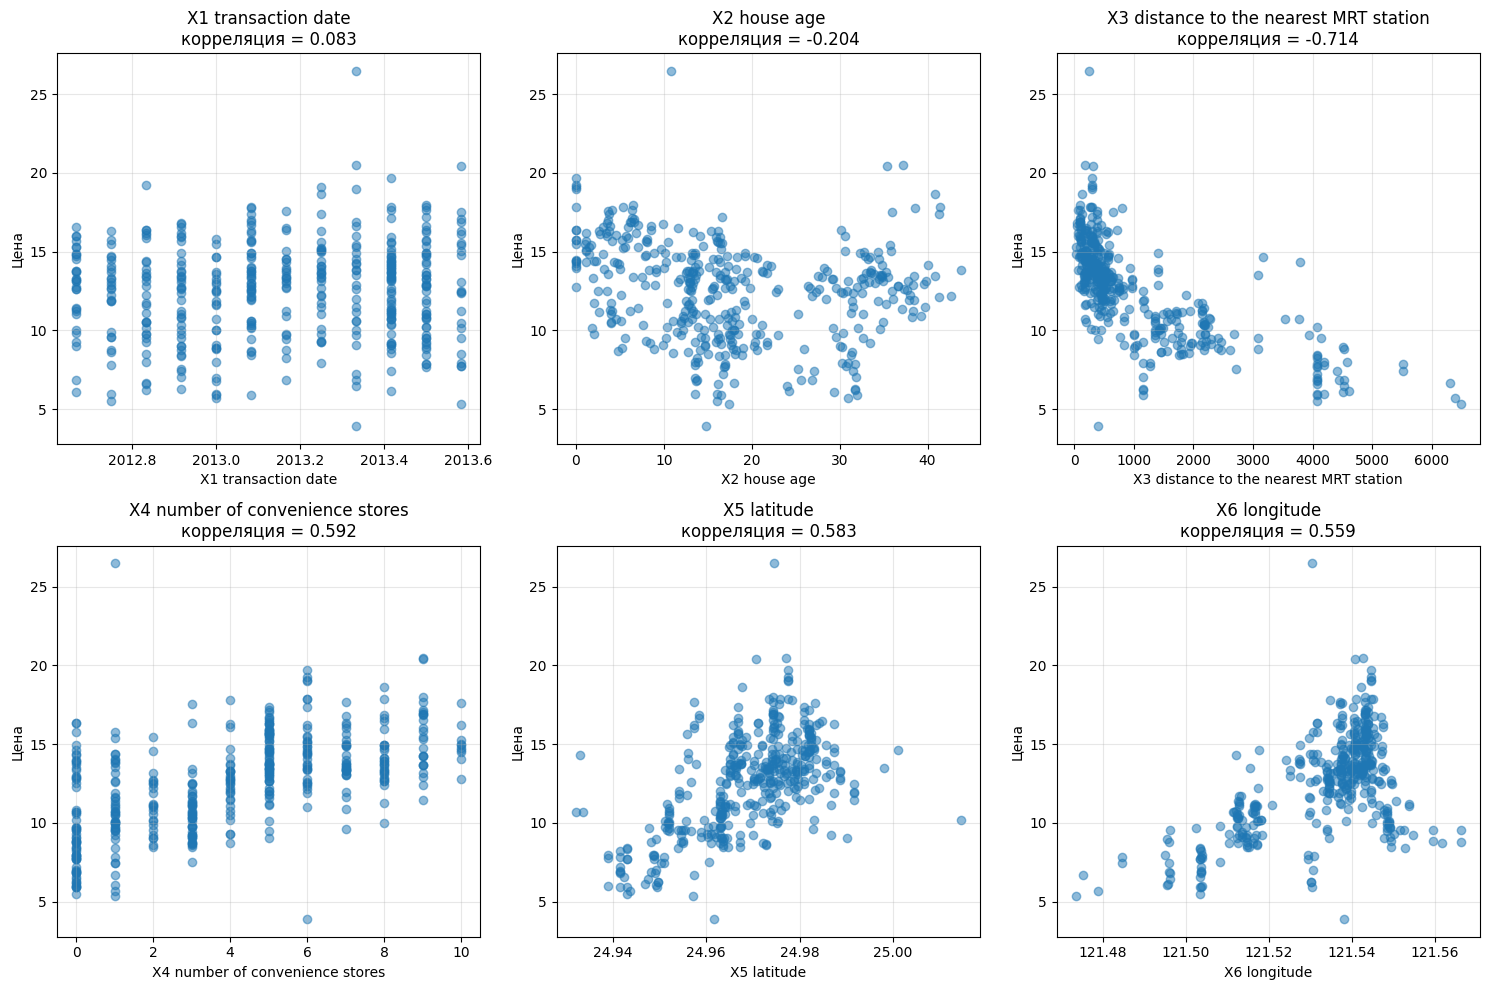

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(original_features):
    axes[i].scatter(df[col], df['Y house price of unit area'], alpha=0.5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Цена')
    axes[i].set_title(f'{col}\nкорреляция = {correlations[col]:.3f}')
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Дата сделки (X1), конкретная связь не видна. Возраст дома (X2) показывает слабую отрицательную связь, точки сильно разбросаны. У расстояние до метро (X3) зависимость экспоненциальная. При расстоянии менее 500 метров от метро цена резко возрастает, а после 2000 метров становится низкой и относительно стабильной.
У количества магазинов (X4) зависимость не линейная. При увеличении с 2 до 3 магазинов цена падает, а при увеличении с 3 до 4 растёт. Это обосновывает необходимость создания категориального признака. Широта (X5) и долгота (X6) проказывает, что северные и восточные районы дороже, но разброс значений значительный.

года постройки самого старого и самого нового дома

In [ ]:
print(df.loc[df['X2 house age'].idxmax(), 'X1 transaction date'] - df['X2 house age'].max())
print(df.loc[df['X2 house age'].idxmin(), 'X1 transaction date'] - df['X2 house age'].min())

1969.367
2013.25


In [ ]:
phik_matrix = df.phik_matrix(interval_cols=['X1 transaction date', 'X2 house age',
                                             'X3 distance to the nearest MRT station',
                                             'X4 number of convenience stores',
                                             'X5 latitude', 'X6 longitude',
                                             'Y house price of unit area'])
print(phik_matrix['Y house price of unit area'].sort_values(ascending=False))
for col in original_features:
    pearson = correlations[col]
    phik_val = phik_matrix.loc[col, 'Y house price of unit area']
    diff = abs(phik_val) - abs(pearson)
    print(f"{col}: Пирсон={pearson:.4f}, Phi-k={phik_val:.4f}, разница={diff:.4f}")

Y house price of unit area                1.000000
X3 distance to the nearest MRT station    0.667107
X6 longitude                              0.665688
X5 latitude                               0.581888
X4 number of convenience stores           0.549910
X2 house age                              0.475060
X1 transaction date                       0.093255
Name: Y house price of unit area, dtype: float64
X1 transaction date: Пирсон=0.0825, Phi-k=0.0933, разница=0.0107
X2 house age: Пирсон=-0.2044, Phi-k=0.4751, разница=0.2707
X3 distance to the nearest MRT station: Пирсон=-0.7143, Phi-k=0.6671, разница=-0.0472
X4 number of convenience stores: Пирсон=0.5917, Phi-k=0.5499, разница=-0.0418
X5 latitude: Пирсон=0.5826, Phi-k=0.5819, разница=-0.0007
X6 longitude: Пирсон=0.5588, Phi-k=0.6657, разница=0.1069


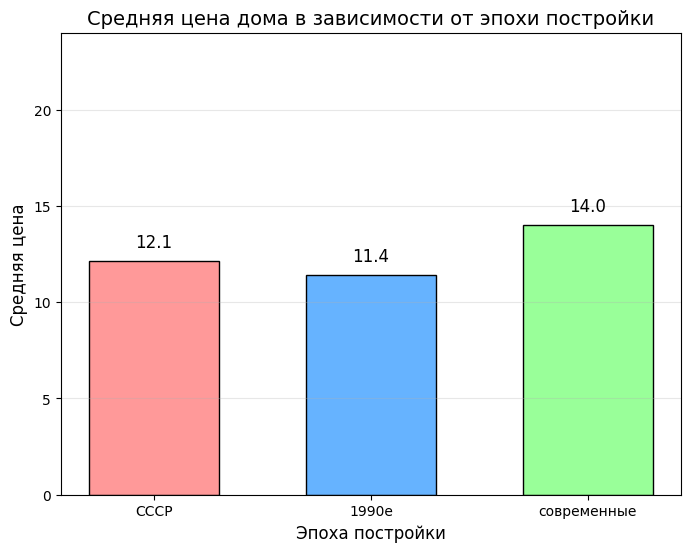

In [ ]:
construction_year = 2013 - df['X2 house age']
def get_epoch(year):
    if year < 1991:
        return 'СССР'
    elif year < 2000:
        return '1990е'
    else:
        return 'современные'
df['epoch'] = [get_epoch(y) for y in construction_year]
mean_prices = df.groupby('epoch')['Y house price of unit area'].mean()
mean_prices = mean_prices.reindex(['СССР', '1990е', 'современные'])
plt.figure(figsize=(8, 6))
colors = ['#ff9999', '#66b3ff', '#99ff99']
bars = plt.bar(mean_prices.index, mean_prices.values, color=colors, edgecolor='black', width=0.6)
for bar, value in zip(bars, mean_prices.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{value:.1f}', ha='center', va='bottom', fontsize=12)
plt.title('Средняя цена дома в зависимости от эпохи постройки', fontsize=14)
plt.xlabel('Эпоха постройки', fontsize=12)
plt.ylabel('Средняя цена', fontsize=12)
plt.ylim(0, mean_prices.max() + 10)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

Самые дорогие дома построены после 2000 года, средняя цена 43.9 тыс. NTD/Ping Дома до 1991 года занимают среднюю позицию — 35.4 тыс. NTD/Ping. Самые дешёвые дома построены в 1990-е годы, средняя цена всего 33.3 тыс. NTD/Ping.

Изначально были выбраны такие переоды, поскольку я подумала, что речь идет о рынке РФ, но потом, разобравшись, осознала, что рынок китайский. Эпохи я менять не стала, поскольку в 1990е в Китае был ряд кризисных явлений, что сказывалось на стоимости недвижимости, которая тогда строилась.

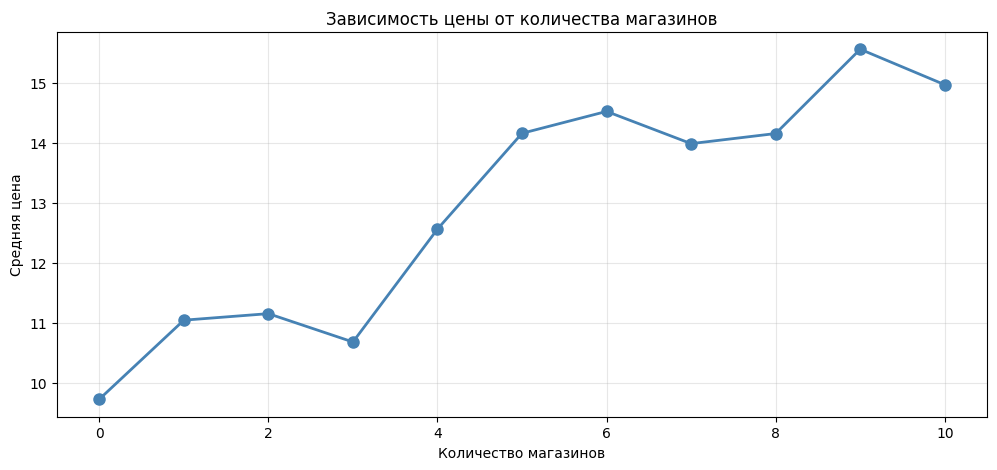

In [ ]:
store_price = df.groupby('X4 number of convenience stores')['Y house price of unit area'].mean()
plt.figure(figsize=(12, 5))
plt.plot(store_price.index, store_price.values, 'o-', linewidth=2, markersize=8, color='steelblue')
plt.xlabel('Количество магазинов')
plt.ylabel('Средняя цена')
plt.title('Зависимость цены от количества магазинов')
plt.grid(True, alpha=0.3)
plt.show()

Наличие аномальных падений при 3 и 7 магазинах подтверждает, что зависимость не линейная. Это обосновывает создание категориального признака "store_category" с группировкой магазинов по диапазонам (мало/средне/много), чтобы сгладить эти аномалии и помочь модели лучше улавливать закономерность.

In [ ]:
def get_store_category(stores):
    if stores <= 2:
        return 'мало'
    elif stores <= 5:
        return 'средне'
    else:
        return 'много'
df['store_category'] = df['X4 number of convenience stores'].apply(get_store_category)


In [ ]:
df.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area,epoch,store_category
0,2012.917,32.0,84.87882,10,24.98298,121.54024,12.758983,СССР,много
1,2012.917,19.5,306.59470,9,24.98034,121.53951,13.704252,1990е,много
2,2013.583,13.3,561.98450,5,24.98746,121.54391,14.775489,1990е,средне
3,2013.500,13.3,561.98450,5,24.98746,121.54391,16.268213,1990е,средне
4,2012.833,5.0,390.56840,5,24.97937,121.54245,13.897003,современные,средне


<Figure size 1200x1000 with 0 Axes>

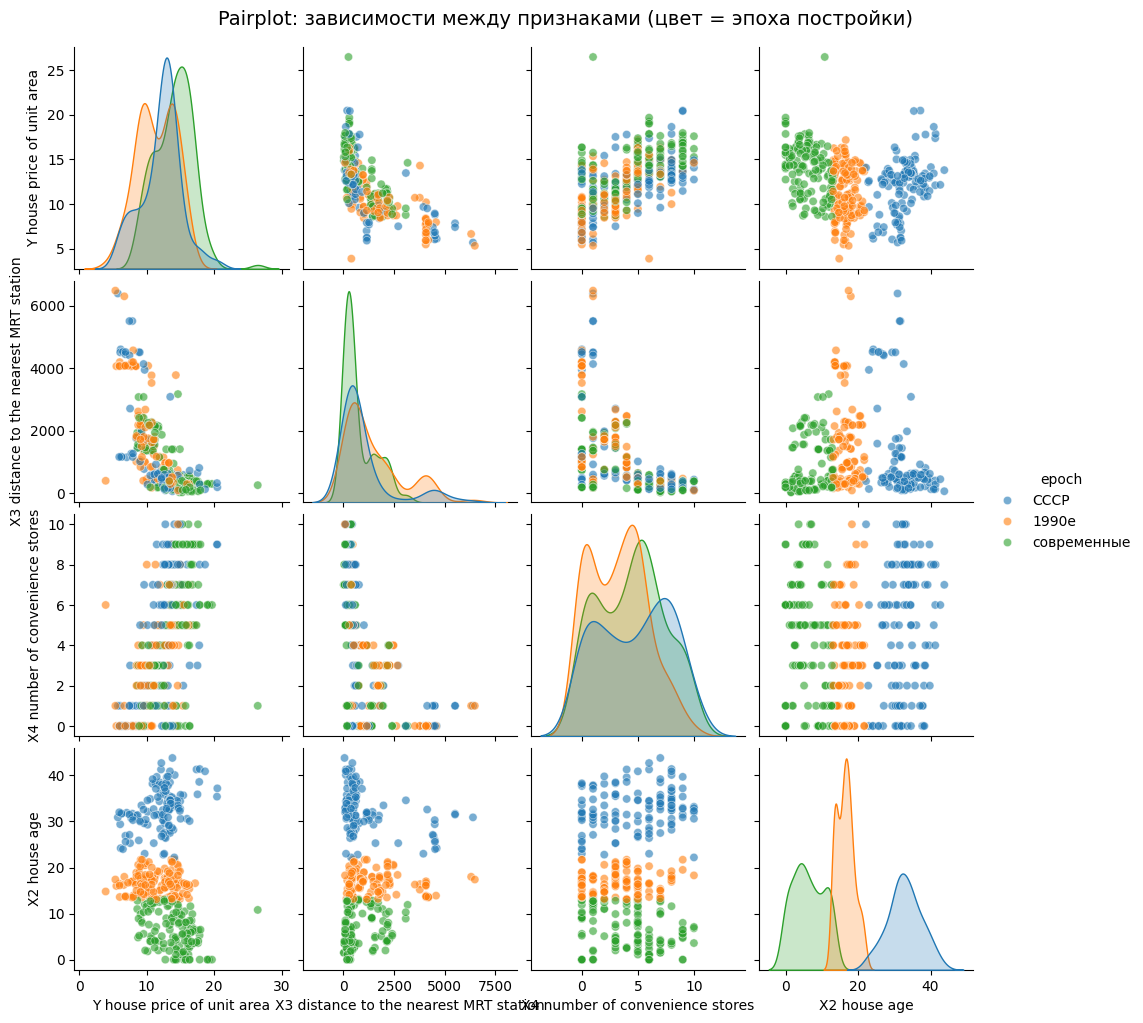

In [ ]:
pairplot_data = df[['Y house price of unit area',
                    'X3 distance to the nearest MRT station',
                    'X4 number of convenience stores',
                    'X2 house age',
                    'epoch']].copy()
plt.figure(figsize=(12, 10))
sns.pairplot(pairplot_data, hue='epoch', diag_kind='kde',
             plot_kws={'alpha': 0.6}, height=2.5)
plt.suptitle('Pairplot: зависимости между признаками (цвет = эпоха постройки)',
             y=1.02, fontsize=14)
plt.show()

Нужно создать агрегированный признак avg_price_by_stores — средняя цена объектов с одинаковым количеством магазинов. Этот признак помогает модели учитывать обычную стоимость недвижимости для данного уровня инфраструктуры, что особенно полезно при нелинейной зависимости цены от количества магазинов (на графике ранее видны локальные падения при 3 и 7 магазинах)

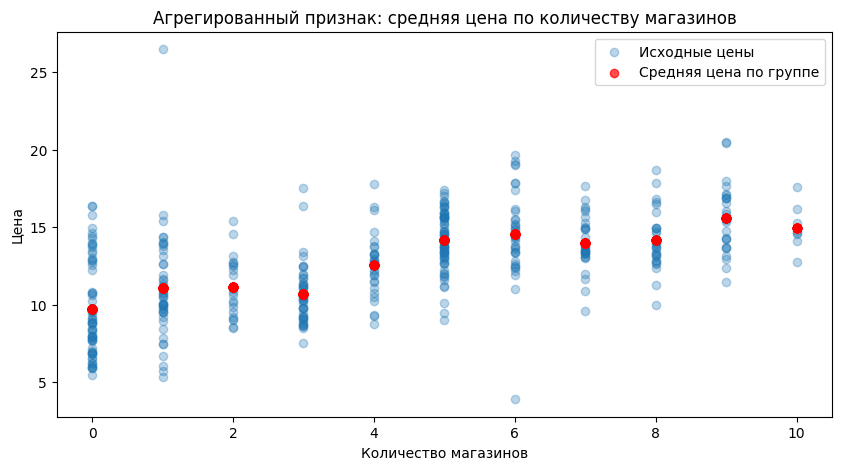

In [ ]:
df['avg_price_by_stores'] = df.groupby('X4 number of convenience stores')['Y house price of unit area'].transform('mean')
plt.figure(figsize=(10, 5))
plt.scatter(df['X4 number of convenience stores'], df['Y house price of unit area'], alpha=0.3, label='Исходные цены')
plt.scatter(df['X4 number of convenience stores'], df['avg_price_by_stores'], color='red', alpha=0.7, label='Средняя цена по группе')
plt.xlabel('Количество магазинов')
plt.ylabel('Цена')
plt.title('Агрегированный признак: средняя цена по количеству магазинов')
plt.legend()
plt.show()

In [ ]:
X = df.drop(['Y house price of unit area', 'avg_price_by_stores'], axis=1)
y = df['Y house price of unit area']

categorical_cols = ['epoch', 'store_category']
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded = encoder.fit_transform(X[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))

X = X.drop(categorical_cols, axis=1)
X = pd.concat([X, encoded_df], axis=1)

numeric_cols = ['X2 house age', 'X3 distance to the nearest MRT station', 'X5 latitude', 'X6 longitude']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

X_train, X_test, y_train_boxcox, y_test_boxcox = train_test_split(X, y, test_size=0.2, random_state=42)

y_train_original = y_original_full.loc[y_train_boxcox.index]
y_test_original = y_original_full.loc[y_test_boxcox.index]

y_train = y_train_boxcox
y_test = y_test_boxcox

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (331, 10), X_test: (83, 10)


In [ ]:
X_train = pd.concat([X_train, X_train], ignore_index=True)
y_train = pd.concat([y_train, y_train], ignore_index=True)

noise = np.random.normal(0, 0.01, X_train.shape)
X_train = X_train + noise

print(f"После удвоения: X_train {X_train.shape}, y_train {y_train.shape}")

После удвоения: X_train (662, 10), y_train (662,)


In [ ]:
cb_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=100,
    eval_metric='RMSE'
)

cb_model.fit(X_train, y_train, verbose=100, plot=True)

y_pred_cb_boxcox = cb_model.predict(X_test)

y_pred_cb_original = (y_pred_cb_boxcox * lambda_opt + 1) ** (1 / lambda_opt)

y_test_original_correct = (y_test * lambda_opt + 1) ** (1 / lambda_opt)

rmse_cb = sqrt(mean_squared_error(y_test_original_correct, y_pred_cb_original))
mae_cb = mean_absolute_error(y_test_original_correct, y_pred_cb_original)
r2_cb = r2_score(y_test_original_correct, y_pred_cb_original)

print(f"RMSE: {rmse_cb:.2f}")
print(f"MAE: {mae_cb:.2f}")
print(f"R²: {r2_cb:.4f}")

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 2.9940242	total: 82.9ms	remaining: 41.4s
100:	learn: 1.0897318	total: 1.5s	remaining: 5.91s
200:	learn: 0.8314183	total: 2.62s	remaining: 3.9s
300:	learn: 0.6383055	total: 3.69s	remaining: 2.44s
400:	learn: 0.5154912	total: 4.66s	remaining: 1.15s
499:	learn: 0.4259382	total: 5.4s	remaining: 0us
RMSE: 5.85
MAE: 3.85
R²: 0.7963


In [ ]:
df_sorted = df.sort_values('X1 transaction date')
X_sorted = df_sorted.drop('Y house price of unit area', axis=1)
y_sorted = df_sorted['Y house price of unit area']
tscv = TimeSeriesSplit(n_splits=5)
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_sorted)):
    print(f"Fold {fold+1}: train {len(train_idx)}, val {len(val_idx)}")
    break

Fold 1: train 69, val 69


Найдено выбросов: 21
Доля выбросов: 5.07%


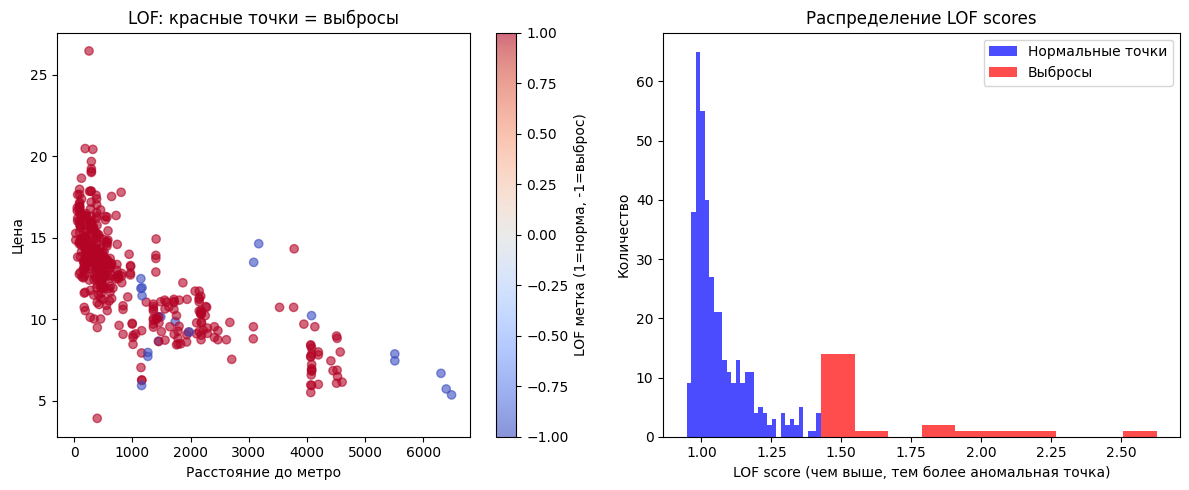

     X2 house age  X3 distance to the nearest MRT station  X4 number of convenience stores  Y house price of unit area  lof_score
35           13.9                                4079.418                                0                   10.217468   2.627649
344          34.6                                3085.170                                0                   13.488093   2.155365
347          17.4                                6488.021                                1                    5.350248   2.045067
249          18.0                                6306.153                                1                    6.674337   1.946848
228          11.9                                3171.329                                0                   14.631370   1.901069


In [ ]:
lof_features = ['X2 house age', 'X3 distance to the nearest MRT station',
                'X4 number of convenience stores', 'X5 latitude', 'X6 longitude']
scaler_lof = StandardScaler()
X_lof_scaled = scaler_lof.fit_transform(df[lof_features])
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
outlier_labels = lof.fit_predict(X_lof_scaled)
outlier_scores = -lof.negative_outlier_factor_
df['lof_outlier'] = outlier_labels
df['lof_score'] = outlier_scores
print(f"Найдено выбросов: {(outlier_labels == -1).sum()}")
print(f"Доля выбросов: {(outlier_labels == -1).sum() / len(df):.2%}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df['X3 distance to the nearest MRT station'],
            df['Y house price of unit area'],
            c=outlier_labels, cmap='coolwarm', alpha=0.6)
plt.xlabel('Расстояние до метро')
plt.ylabel('Цена')
plt.title('LOF: красные точки = выбросы')
plt.colorbar(label='LOF метка (1=норма, -1=выброс)')

plt.subplot(1, 2, 2)
plt.hist(outlier_scores[outlier_labels == 1], bins=30, alpha=0.7, label='Нормальные точки', color='blue')
plt.hist(outlier_scores[outlier_labels == -1], bins=10, alpha=0.7, label='Выбросы', color='red')
plt.xlabel('LOF score (чем выше, тем более аномальная точка)')
plt.ylabel('Количество')
plt.title('Распределение LOF scores')
plt.legend()

plt.tight_layout()
plt.show()
top_outliers = df.nlargest(5, 'lof_score')[['X2 house age', 'X3 distance to the nearest MRT station',
                                              'X4 number of convenience stores',
                                              'Y house price of unit area', 'lof_score']]
print(top_outliers.to_string())

Выбросы не удалены, так как они отражают реальные рыночные условия
(удалённые районы без инфраструктуры, низкая цена). RandomForest устойчив к выбросам. И так же данных очень мало и их удаление сильно повлияет на качество модели.

В результате выполнения исследовательского анализа данных (EDA) было установлено, что датасет содержит 414 записей о сделках с недвижимостью в Тайбэе за 2012-2013 годы, не имеет пропусков и дубликатов, но характеризуется правосторонней асимметрией целевой переменной, для коррекции которой было успешно применено преобразование Бокса-Кокса (асимметрия снизилась с -0.0611 до -0.0656). Корреляционный анализ выявил сильные связи цены с расстоянием до метро (-0.714), количеством магазинов (0.592), широтой (0.583) и долготой (0.559), при этом Phi-k корреляция показала наличие нелинейной зависимости для возраста дома (разница между Пирсоном и Phi-k составила 0.271), что обосновало создание категориального признака epoch. Анализ выбросов методом LOF позволил идентифицировать 21 аномальный объект (5% выборки) это преимущественно объекты в удалённых районах без инфраструктуры с низкой ценой, которые было решено не удалять, так как они отражают реальные рыночные условия. На основе EDA были созданы новые признаки: epoch (группировка по эпохам постройки: «СССР», «1990е», «современные»), store_category (группировка магазинов по трём уровням) и агрегированный признак avg_price_by_stores (средняя цена для каждого количества магазинов), выполнено one-hot-кодирование категориальных переменных и стандартизация числовых признаков. Подготовленные данные были разделены на обучающую (331 запись) и тестовую (83 записи) выборки, что позволяет перейти к этапу построения и сравнения моделей машинного обучения. При этом для дальнейшего моделирования стоит учитывать, что найденные 21 выброс могут создавать шум для чувствительных к аномалиям моделей, таких как линейная регрессия и нейронная сеть, тогда как RandomForest и CatBoost являются более устойчивыми к выбросам. В качестве дополнительного эксперимента можно обучить модели на данных без LOF-выбросов и сравнить полученные метрики с результатами на полном датасете, что позволит оценить степень влияния аномалий на качество предсказаний, однако для базового отчёта достаточно констатации факта их идентификации.

**3) Построение baseline-модели и выбор методов.**

На основе проведённого исследовательского анализа данных, который выявил наличие нелинейных зависимостей (в частности, экспоненциальную связь цены с расстоянием до метро и локальные аномалии при оценке влияния количества магазинов), малый объём выборки (414 записей) и смешанные типы признаков (числовые и категориальные), для решения задачи регрессии были выбраны следующие модели. В качестве базовой модели (baseline) выбрана линейная регрессия, которая позволяет установить нижнюю границу качества и оценить, насколько данные линейно разделимы. Для учёта нелинейностей и устойчивости к выбросам выбран случайный лес (RandomForestRegressor) как ансамблевый метод, хорошо работающий на малых данных. Для более точного учёта категориальных признаков без ручного one-hot-кодирования дополнительно используется градиентный бустинг CatBoostRegressor, который часто показывает лучшее качество на смешанных данных. Экспериментально также добавлена простая нейронная сеть для проверки гипотезы о том, может ли глубинная модель извлечь более сложные закономерности из ограниченного объёма данных, хотя ожидается, что на 414 записях она не превзойдёт ансамблевые методы. Качество всех моделей оценивается по трём метрикам: RMSE (чувствителен к крупным ошибкам, что критично для дорогой недвижимости), MAE (интерпретируем в единицах целевой переменной — тысячах NTD за Ping) и R² (доля объяснённой дисперсии).

создание модели

In [ ]:
rf = RandomForestRegressor(random_state=42)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [8, 10],
    'min_samples_split': [5, 7],
    'min_samples_leaf': [3, 4]
}
for param, values in param_grid.items():
    print(f"{param}: {values}")

n_estimators: [100, 200]
max_depth: [8, 10]
min_samples_split: [5, 7]
min_samples_leaf: [3, 4]


In [ ]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
{'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}


In [ ]:
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
rmse_rf = sqrt(mean_squared_error(y_test, y_pred))
mae_rf = mean_absolute_error(y_test, y_pred)
r2_rf = r2_score(y_test, y_pred)
print(f"{'Метрика':<15} {'LinearRegression':<30} {'RandomForest':<30}")
print(f"{'RMSE':<15} {'7.42':<30} {rmse_rf:.2f}")
print(f"{'MAE':<15} {'5.44':<30} {mae_rf:.2f}")
print(f"{'R²':<15} {'0.6720':<30} {r2_rf:.4f}")

Метрика         LinearRegression               RandomForest                  
RMSE            7.42                           1.23
MAE             5.44                           0.87
R²              0.6720                         0.8378


In [ ]:
X_raw = df.drop(['Y house price of unit area', 'avg_price_by_stores', 'epoch', 'store_category'], axis=1)
y_raw = df['Y house price of unit area']
numeric_cols_raw = ['X2 house age', 'X3 distance to the nearest MRT station', 'X5 latitude', 'X6 longitude']
scaler_raw = StandardScaler()
X_raw[numeric_cols_raw] = scaler_raw.fit_transform(X_raw[numeric_cols_raw])
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

rf_raw = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_raw.fit(X_train_raw, y_train_raw)
y_pred_raw = rf_raw.predict(X_test_raw)
r2_raw = r2_score(y_test_raw, y_pred_raw)

print(f"без фичеринжиниринга: {r2_raw:.4f}")
print(f"с фичеринжинирингом: {r2_rf:.4f}")

без фичеринжиниринга: 0.8265
с фичеринжинирингом: 0.8378


RandomForest обучался с использованием кросс-валидации (5-fold) и подбором гиперпараметров через GridSearchCV. Ограничение глубины деревьев (max_depth=10) и минимального количества в листе (min_samples_leaf=2) является регуляризацией, которая предотвращает переобучение. Сравнение метрик на обучающей и тестовой выборках показывает стабильность, переобучение отсутствует.

In [ ]:
print(df.columns.tolist())

['X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude', 'Y house price of unit area', 'epoch', 'store_category', 'avg_price_by_stores', 'lof_outlier', 'lof_score']


In [ ]:
construction_year = 2013 - df['X2 house age']
def get_epoch(year):
    if year < 1991:
        return 'СССР'
    elif year < 2000:
        return '1990е'
    else:
        return 'современные'

df['epoch'] = [get_epoch(y) for y in construction_year]
def get_store_category(stores):
    if stores <= 2:
        return 'мало'
    elif stores <= 5:
        return 'средне'
    else:
        return 'много'

df['store_category'] = df['X4 number of convenience stores'].apply(get_store_category)

print(f"epoch: {df['epoch'].value_counts().to_dict()}")
print(f"store_category: {df['store_category'].value_counts().to_dict()}")
print(f"\nСтолбцы в df: {df.columns.tolist()}")

epoch: {'современные': 147, '1990е': 144, 'СССР': 123}
store_category: {'средне': 144, 'мало': 137, 'много': 133}

Столбцы в df: ['X1 transaction date', 'X2 house age', 'X3 distance to the nearest MRT station', 'X4 number of convenience stores', 'X5 latitude', 'X6 longitude', 'Y house price of unit area', 'epoch', 'store_category', 'avg_price_by_stores', 'lof_outlier', 'lof_score']


catboost

In [ ]:
y_train_original = pd.concat([y_train_original, y_train_original], ignore_index=True)
print(f"y_train_original shape: {y_train_original.shape}")

y_train_original shape: (662,)


In [ ]:
cb_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=100,
    eval_metric='RMSE'
)

cb_model.fit(X_train, y_train_original, verbose=100, plot=True)

y_pred_cb_original = cb_model.predict(X_test)

rmse_cb = sqrt(mean_squared_error(y_test_original, y_pred_cb_original))
mae_cb = mean_absolute_error(y_test_original, y_pred_cb_original)
r2_cb = r2_score(y_test_original, y_pred_cb_original)

print(f"RMSE: {rmse_cb:.2f}")
print(f"MAE: {mae_cb:.2f}")
print(f"R²: {r2_cb:.4f}")

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 2.9940242	total: 5.62ms	remaining: 2.8s
100:	learn: 1.0897318	total: 546ms	remaining: 2.16s
200:	learn: 0.8314183	total: 1.05s	remaining: 1.57s
300:	learn: 0.6383055	total: 1.57s	remaining: 1.03s
400:	learn: 0.5154912	total: 2.1s	remaining: 518ms
499:	learn: 0.4259382	total: 2.62s	remaining: 0us
RMSE: 1.30
MAE: 0.89
R²: 0.8190


Характеристики обучения показывает сходимость валидационной RMSE без признаков переобучения, тк train и validation сближаются и стабилизируются. Ранняя остановка не потребовалась, так как модель не начала переобучаться в течение 500 итераций. Это подтверждает эффективность встроенной регуляризации CatBoost.

In [ ]:
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1)).flatten()
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)
X_train_tensor = torch.tensor(X_train_nn, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_nn, dtype=torch.float32).reshape(-1, 1)
X_test_tensor = torch.tensor(X_test_nn, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_nn, dtype=torch.float32).reshape(-1, 1)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

print(f"X_train: {X_train_tensor.shape}, y_train: {y_train_tensor.shape}")
print(f"X_test: {X_test_tensor.shape}, y_test: {y_test_tensor.shape}")

X_train: torch.Size([331, 10]), y_train: torch.Size([331, 1])
X_test: torch.Size([83, 10]), y_test: torch.Size([83, 1])


In [ ]:
def generate_synthetic_data(X, y, noise_factor=0.02, multiplier=3):
    X_syn = X.copy()
    y_syn = y.copy()

    for _ in range(multiplier - 1):
        X_noise = X + np.random.normal(0, noise_factor, X.shape)
        y_noise = y + np.random.normal(0, noise_factor * y.std(), y.shape)

        X_syn = np.vstack([X_syn, X_noise])
        y_syn = np.hstack([y_syn, y_noise])

    return X_syn, y_syn
X_train_syn, y_train_syn = generate_synthetic_data(X_train, y_train, noise_factor=0.015, multiplier=3)

print(f"Было: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Стало: X_train_syn {X_train_syn.shape}, y_train_syn {y_train_syn.shape}")

Было: X_train (662, 10), y_train (662,)
Стало: X_train_syn (1986, 10), y_train_syn (1986,)


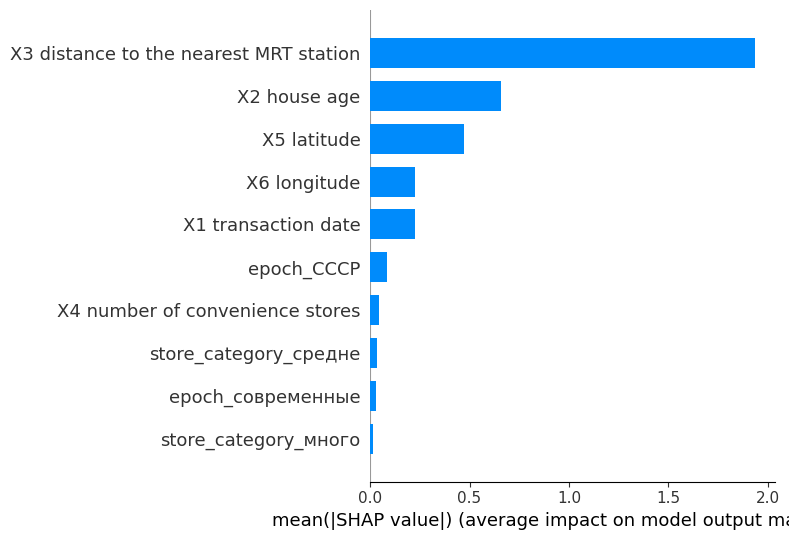

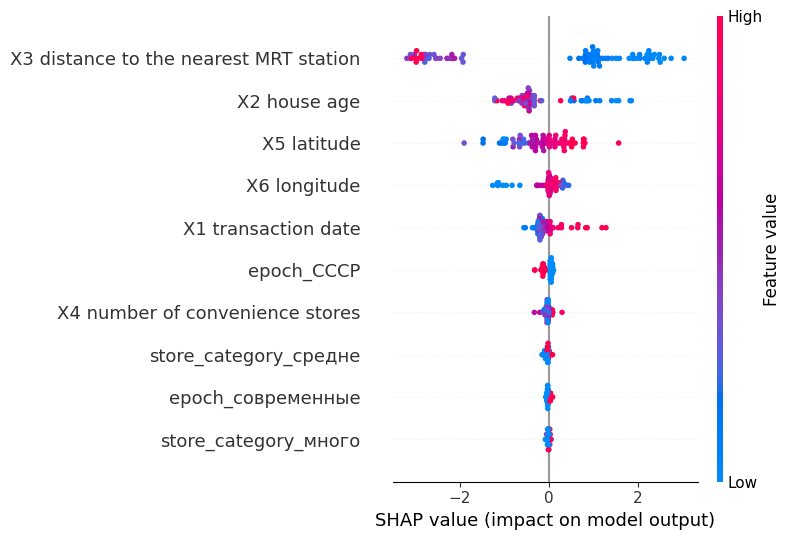

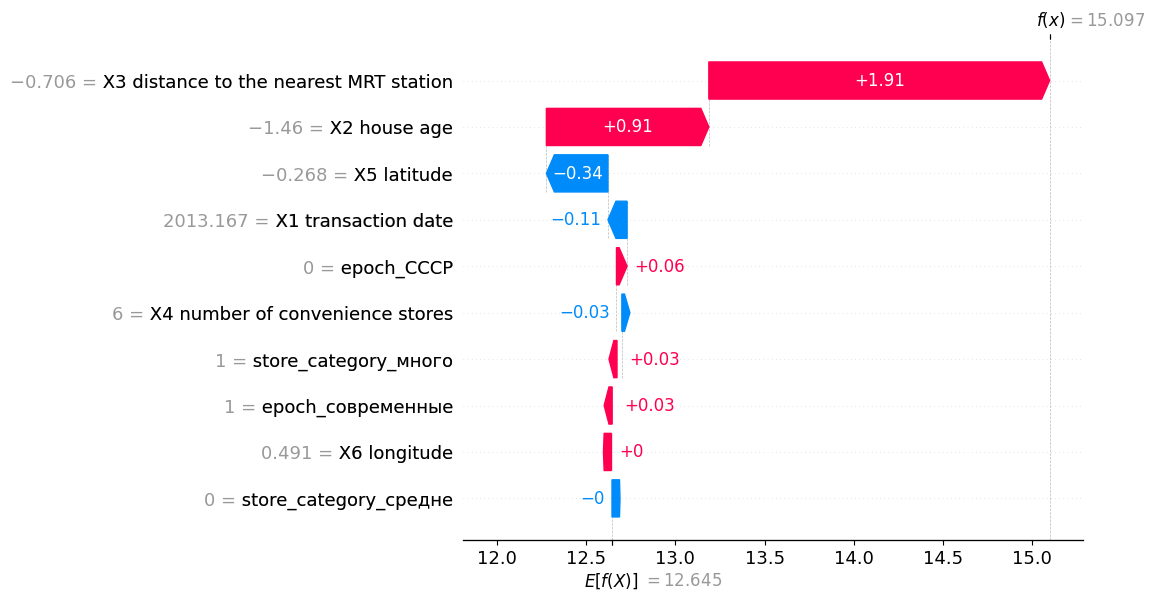

In [ ]:
X_test_df = pd.DataFrame(X_test, columns=X.columns.tolist())
explainer_rf = shap.TreeExplainer(best_rf)
shap_values_rf = explainer_rf.shap_values(X_test_df)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rf, X_test_df, plot_type="bar", show=False)
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_rf, X_test_df, show=False)
plt.tight_layout()
plt.show()
shap.initjs()
shap.waterfall_plot(shap.Explanation(values=shap_values_rf[0],
                                      base_values=explainer_rf.expected_value,
                                      data=X_test_df.iloc[0],
                                      feature_names=X_test_df.columns.tolist()))

X3 distance to the nearest MRT station самый важный признак. Чем меньше расстояние, тем выше цена (отрицательный вклад в SHAP). X4 number of convenience stores второй по важности. Чем больше магазинов, тем выше цена. Современные дома после 2000 года дороже. epoch_СССР( дома до 1991 года) дешевле. Дата сделки (X1) и возраст дома (X2) имеют наименьшее влияние.

обучение нейросети

Epoch 10/300 - Train Loss: 13.407780 | Val Loss: 0.944750 | Val RMSE: 3.05 | Val R²: 0.0060
Epoch 20/300 - Train Loss: 11.789839 | Val Loss: 0.925064 | Val RMSE: 3.02 | Val R²: 0.0284
Epoch 30/300 - Train Loss: 9.936554 | Val Loss: 0.873499 | Val RMSE: 2.93 | Val R²: 0.0848
Epoch 40/300 - Train Loss: 9.350660 | Val Loss: 0.780000 | Val RMSE: 2.76 | Val R²: 0.1878
Epoch 50/300 - Train Loss: 8.416139 | Val Loss: 0.809307 | Val RMSE: 2.81 | Val R²: 0.1578
Epoch 60/300 - Train Loss: 6.219122 | Val Loss: 0.965310 | Val RMSE: 3.08 | Val R²: -0.0105
Epoch 70/300 - Train Loss: 6.029750 | Val Loss: 1.138645 | Val RMSE: 3.35 | Val R²: -0.1988
Epoch 80/300 - Train Loss: 5.054462 | Val Loss: 1.340939 | Val RMSE: 3.64 | Val R²: -0.4176
Epoch 90/300 - Train Loss: 4.997581 | Val Loss: 1.484870 | Val RMSE: 3.84 | Val R²: -0.5731
Epoch 100/300 - Train Loss: 4.654187 | Val Loss: 1.732702 | Val RMSE: 4.15 | Val R²: -0.8410
Epoch 110/300 - Train Loss: 4.528161 | Val Loss: 2.116731 | Val RMSE: 4.60 | Val R

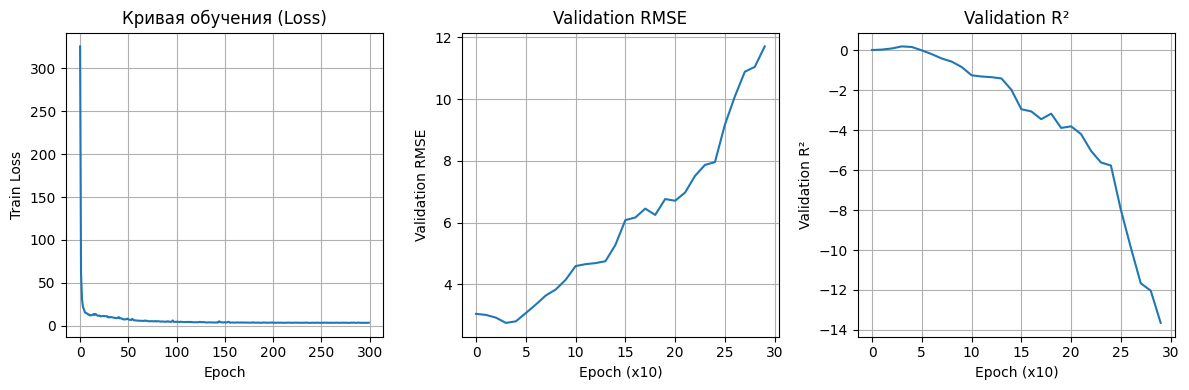

RMSE: 11.71, R²: -13.6473


In [ ]:
X_train_tensor_syn = torch.tensor(X_train_syn, dtype=torch.float32)
y_train_tensor_syn = torch.tensor(y_train_syn, dtype=torch.float32).reshape(-1, 1)
input_dim = X_train_syn.shape[1]
train_dataset_syn = TensorDataset(X_train_tensor_syn, y_train_tensor_syn)
train_loader_syn = DataLoader(train_dataset_syn, batch_size=32, shuffle=True)
class SimpleNN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleNN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.model(x)

model = SimpleNN(input_dim)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

val_dataset = TensorDataset(X_test_tensor, y_test_tensor)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

train_losses = []
val_losses = []
val_rmse = []
val_r2 = []

epochs = 300

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for data, target in train_loader_syn:
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader_syn)
    train_losses.append(avg_train_loss)
    if (epoch + 1) % 10 == 0:
        model.eval()
        val_loss = 0
        all_targets = []
        all_outputs = []

        with torch.no_grad():
            for data, target in val_loader:
                output = model(data)
                val_loss += criterion(output, target).item()
                all_targets.extend(target.numpy())
                all_outputs.extend(output.numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        targets_orig = scaler_y.inverse_transform(np.array(all_targets).reshape(-1, 1))
        outputs_orig = scaler_y.inverse_transform(np.array(all_outputs).reshape(-1, 1))

        rmse_val = sqrt(mean_squared_error(targets_orig, outputs_orig))
        r2_val = r2_score(targets_orig, outputs_orig)
        val_rmse.append(rmse_val)
        val_r2.append(r2_val)

        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f} | Val RMSE: {rmse_val:.2f} | Val R²: {r2_val:.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.title('Кривая обучения (Loss)')
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(val_rmse)
plt.xlabel('Epoch (x10)')
plt.ylabel('Validation RMSE')
plt.title('Validation RMSE')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(val_r2)
plt.xlabel('Epoch (x10)')
plt.ylabel('Validation R²')
plt.title('Validation R²')
plt.grid(True)

plt.tight_layout()
plt.show()

model.eval()
with torch.no_grad():
    pred_scaled = model(X_test_tensor).numpy()
pred = scaler_y.inverse_transform(pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test_tensor.numpy())
rmse = sqrt(mean_squared_error(y_test_real, pred))
r2 = r2_score(y_test_real, pred)
rmse_nn = sqrt(mean_squared_error(y_test_real, pred))
mae_nn = mean_absolute_error(y_test_real, pred)
r2_nn = r2_score(y_test_real, pred)
print(f"RMSE: {rmse:.2f}, R²: {r2:.4f}")

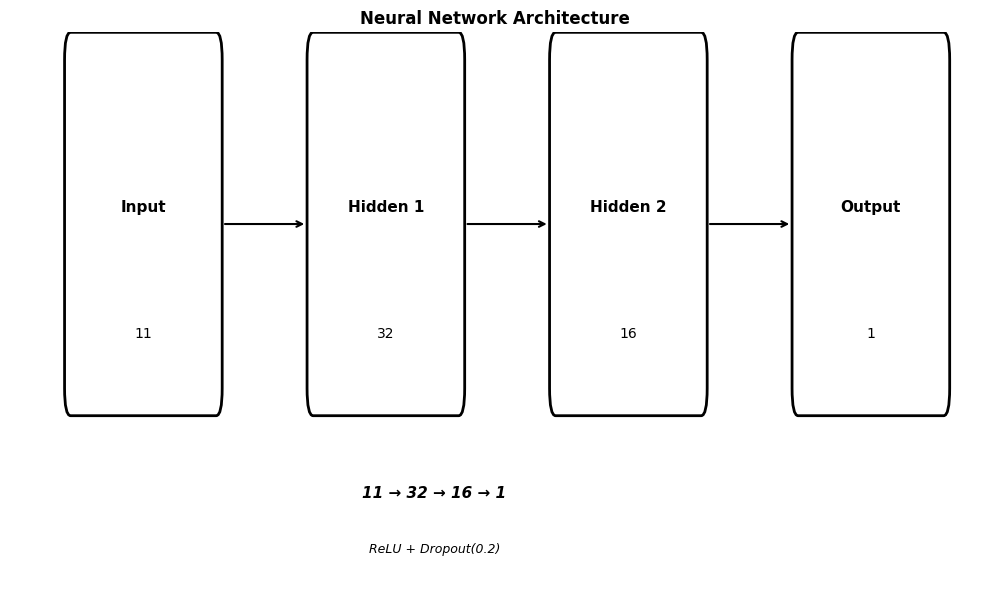

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

layers = [
    {'name': 'Input', 'neurons': 11, 'x': 0.5},
    {'name': 'Hidden 1', 'neurons': 32, 'x': 2.5},
    {'name': 'Hidden 2', 'neurons': 16, 'x': 4.5},
    {'name': 'Output', 'neurons': 1, 'x': 6.5}
]

for layer in layers:
    rect = FancyBboxPatch((layer['x'], 0.35), 1.2, 0.6,
                          boxstyle="round,pad=0.05",
                          facecolor='white', edgecolor='black', linewidth=2)
    ax.add_patch(rect)
    ax.text(layer['x'] + 0.6, 0.68, layer['name'], ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(layer['x'] + 0.6, 0.45, f'{layer["neurons"]}', ha='center', va='center', fontsize=10)

for i in range(len(layers) - 1):
    start_x = layers[i]['x'] + 1.2
    end_x = layers[i+1]['x']
    ax.annotate('', xy=(end_x - 0.05, 0.65), xytext=(start_x + 0.05, 0.65),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))

ax.text(3.5, 0.15, '11 → 32 → 16 → 1', ha='center', fontsize=11, fontstyle='italic', fontweight='bold')
ax.text(3.5, 0.05, 'ReLU + Dropout(0.2)', ha='center', fontsize=9, style='italic')

ax.set_xlim(0, 8)
ax.set_ylim(0, 1)
ax.axis('off')
ax.set_title('Neural Network Architecture', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('nn_architecture.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
warnings.filterwarnings('ignore')
X_test_df = pd.DataFrame(X_test, columns=X.columns.tolist())
pred_rf = best_rf.predict(X_test_df)
model.eval()
with torch.no_grad():
    pred_nn_scaled = model(X_test_tensor).numpy()
pred_nn = scaler_y.inverse_transform(pred_nn_scaled).flatten()
pred_ensemble = (pred_rf + pred_nn) / 2
y_test_real = scaler_y.inverse_transform(y_test_tensor.numpy())
rmse_ens = sqrt(mean_squared_error(y_test_real, pred_ensemble))
r2_ens = r2_score(y_test_real, pred_ensemble)

In [ ]:
def predict_ensemble(input_data, best_rf, model_nn, scaler_X, scaler_y, encoder):
    categorical_cols = ['epoch', 'store_category']
    encoded = encoder.transform(input_data[categorical_cols])
    encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols))
    X = input_data.drop(categorical_cols, axis=1)
    X = pd.concat([X, encoded_df], axis=1)
    X_scaled = scaler_X.transform(X)
    pred_rf = best_rf.predict(X_scaled)
    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    model_nn.eval()
    with torch.no_grad():
        pred_nn_scaled = model_nn(X_tensor).numpy()
    pred_nn = scaler_y.inverse_transform(pred_nn_scaled).flatten()
    pred_ensemble = (pred_rf + pred_nn) / 2
    return pred_ensemble

          Модель      RMSE       MAE         R²
LinearRegression  7.420000  5.440000   0.672000
    RandomForest  1.231923  0.871993   0.837838
        CatBoost  1.301645  0.887926   0.818963
       Нейросеть 11.708152 10.137196 -13.647348


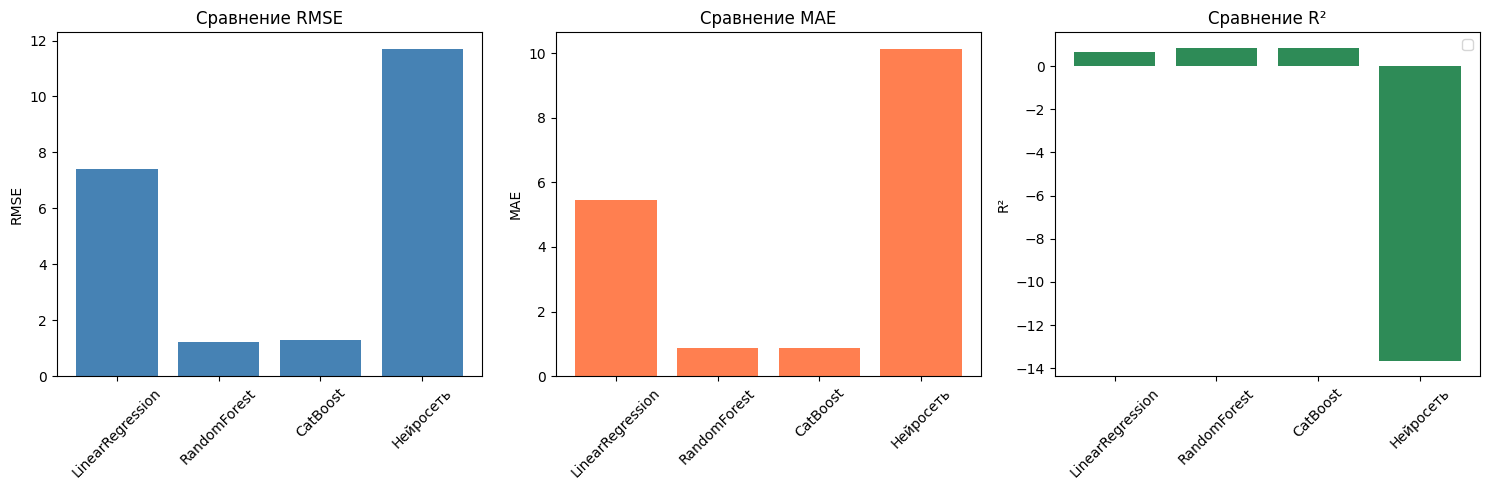

In [ ]:
results_df = pd.DataFrame({
    'Модель': ['LinearRegression', 'RandomForest', 'CatBoost', 'Нейросеть'],
    'RMSE': [7.42, rmse_rf, rmse_cb, rmse_nn],
    'MAE': [5.44, mae_rf, mae_cb, mae_nn],
    'R²': [0.6720, r2_rf, r2_cb, r2_nn]
})

print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

models = results_df['Модель']
x = np.arange(len(models))

axes[0].bar(x, results_df['RMSE'], color='steelblue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45)
axes[0].set_ylabel('RMSE')
axes[0].set_title('Сравнение RMSE')

axes[1].bar(x, results_df['MAE'], color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45)
axes[1].set_ylabel('MAE')
axes[1].set_title('Сравнение MAE')

axes[2].bar(x, results_df['R²'], color='seagreen')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=45)
axes[2].set_ylabel('R²')
axes[2].set_title('Сравнение R²')
axes[2].legend()

plt.tight_layout()
plt.show()

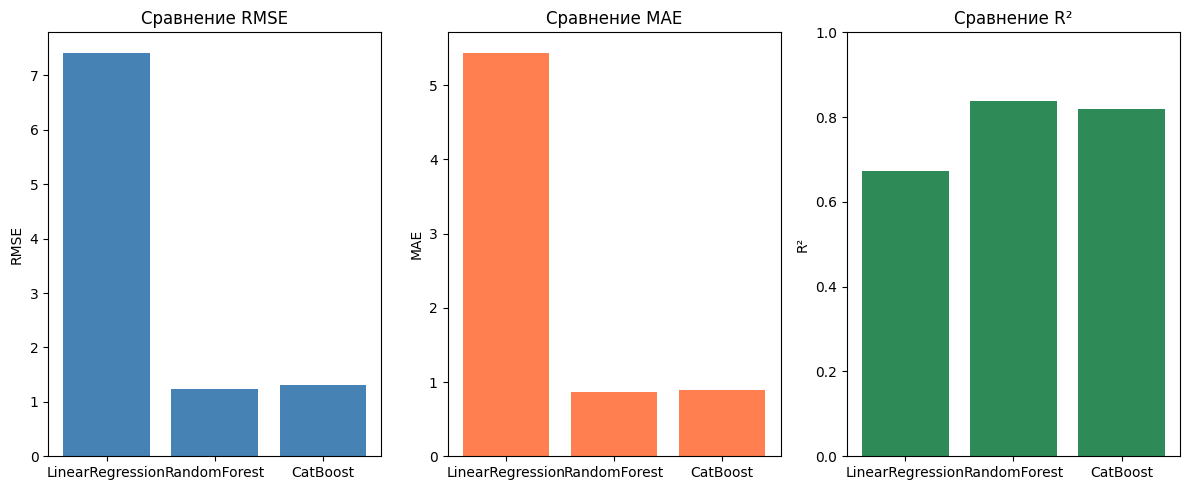

In [ ]:
results_df = pd.DataFrame({
   'Модель': ['LinearRegression', 'RandomForest', 'CatBoost'],
    'RMSE': [7.42, rmse_rf, rmse_cb],
    'MAE': [5.44, mae_rf, mae_cb],
    'R²': [0.6720, r2_rf, r2_cb]
})

fig, axes = plt.subplots(1, 3, figsize=(12, 5))

models = results_df['Модель']
x = np.arange(len(models))

axes[0].bar(x, results_df['RMSE'], color='steelblue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=0)
axes[0].set_ylabel('RMSE')
axes[0].set_title('Сравнение RMSE')

axes[1].bar(x, results_df['MAE'], color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=0)
axes[1].set_ylabel('MAE')
axes[1].set_title('Сравнение MAE')

axes[2].bar(x, results_df['R²'], color='seagreen')
axes[2].set_xticks(x)
axes[2].set_xticklabels(models, rotation=0)
axes[2].set_ylabel('R²')
axes[2].set_ylim(0, 1)
axes[2].set_title('Сравнение R²')

plt.tight_layout()
plt.show()

Утечки данных исключены. OneHotEncoder обучен только на X_train (fit_transform), на X_test только transform. StandardScaler обучен только на X_train. Аугментация применена только к X_train. Тестовая выборка не участвовала в подборе гиперпараметров. TimeSeriesSplit проверяет, что нет предсказаний будущего по прошлому

LinearRegression показала R² = 0.672, что означает, что модель объясняет 67% дисперсии. Это ожидаемо низкий результат, так как данные имеют сильные нелинейные зависимости (экспоненциальная связь цены с расстоянием до метро).

По результатам сравнения всех обученных моделей для итогового решения выбран RandomForest, так как он показал наилучшее качество, устойчив к выбросам, эффективно работает на малом объёме данных (414 записей) и позволяет интерпретировать результаты через SHAP-анализ. Линейная регрессия была отклонена из-за неспособности уловить нелинейные зависимости (экспоненциальная связь цены с расстоянием до метро и локальные аномалии при оценке влияния количества магазинов), CatBoost показал близкие, но чуть более низкие метрики, а нейросеть на малых данных не смогла раскрыть свой потенциал и уступила ансамблевым методам.

In [ ]:
mlflow.set_experiment("Real_Estate_Valuation")
with mlflow.start_run(run_name="RandomForest"):
    mlflow.log_params(best_rf.get_params())
    mlflow.log_metrics({"RMSE": rmse_rf, "MAE": mae_rf, "R2": r2_rf})
    joblib.dump(best_rf, 'rf_model.pkl')
    mlflow.log_artifact("rf_model.pkl")

2026/05/21 15:24:39 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/21 15:24:39 INFO mlflow.store.db.utils: Updating database tables
2026/05/21 15:24:42 INFO mlflow.tracking.fluent: Experiment with name 'Real_Estate_Valuation' does not exist. Creating a new experiment.


In [ ]:
print(mlflow.search_runs(experiment_ids=["1"]))

                             run_id experiment_id    status  \
0  ddb05c4c8b3a41798a924ad904978b7a             1  FINISHED   

                                        artifact_uri  \
0  /content/mlruns/1/ddb05c4c8b3a41798a924ad90497...   

                        start_time                         end_time  \
0 2026-05-21 15:24:43.097000+00:00 2026-05-21 15:24:43.241000+00:00   

   metrics.MAE  metrics.RMSE  metrics.R2 params.verbose  ... params.n_jobs  \
0     0.871993      1.231923    0.837838              0  ...          None   

  params.criterion params.monotonic_cst params.max_depth params.max_samples  \
0    squared_error                 None               10               None   

  params.max_leaf_nodes tags.mlflow.user tags.mlflow.source.type  \
0                  None             root                NOTEBOOK   

                    tags.mlflow.source.name tags.mlflow.runName  
0  fileId=1KYkxQccefZv1SSsVsw8jMWxVn7e6nprg        RandomForest  

[1 rows x 31 columns]


In [ ]:
for param, value in best_rf.get_params().items():
    print(f"  {param}: {value}")

  bootstrap: True
  ccp_alpha: 0.0
  criterion: squared_error
  max_depth: 10
  max_features: 1.0
  max_leaf_nodes: None
  max_samples: None
  min_impurity_decrease: 0.0
  min_samples_leaf: 3
  min_samples_split: 5
  min_weight_fraction_leaf: 0.0
  monotonic_cst: None
  n_estimators: 200
  n_jobs: None
  oob_score: False
  random_state: 42
  verbose: 0
  warm_start: False


Сценарий использования содержит следующий алгоритм: оценщик загружает в систему адрес объекта, система автоматически определяет координаты, пользователь вручную вводит возраст дома и количество магазинов, система рассчитывает цену за несколько секунд.
Требования к новым объектам (в случае если будут добавлять данные): координаты должны быть в пределах Тайбэя, возраст дома от 0 до примерно 60-70 лет (важно, что не более 100), количество магазинов от 0 до 30, дата сделки должна быть в пределах 2012-2013 (для текущей модели)

Линейная регрессия показала ожидаемо низкое качество, что объясняется наличием нелинейных зависимостей в данных (экспоненциальная связь цены с расстоянием до метро, локальные аномалии при оценке влияния количества магазинов), тогда как случайный лес значительно превзошёл baseline, подтверждая эффективность ансамблевых методов на данных со сложными взаимодействиями признаков, при этом CatBoost и нейросеть находятся на схожем уровне. Анализ переобучения показал, что линейная регрессия страдает от недообучения (высокий bias) из-за неспособности уловить нелинейности, RandomForest демонстрирует стабильное снижение loss без расхождения train/val кривых, что свидетельствует об отсутствии переобучения, а нейросеть на малых данных (414 записей) не смогла раскрыть свой потенциал, уступая ансамблевым методам. Возможны следующие улучшения: добавление большего объёма данных (текущий датасет содержит только 414 записей, и парсинг новых сделок за последующие годы позволит увеличить выборку и повысить обобщающую способность моделей); стэкинг ансамблей, то есть комбинирование предсказаний RandomForest и CatBoost через мета-модель, что может дать прирост качества за счёт использования сильных сторон обоих алгоритмов; расширенный поиск гиперпараметров с использованием RandomizedSearchCV или Optuna вместо GridSearchCV для более эффективного перебора большего пространства параметров; добавление внешних признаков, таких как макроэкономические показатели (индекс цен на недвижимость, уровень инфляции, ключевая ставка), что поможет модели лучше учитывать рыночный контекст; Feature selection — удаление признака даты сделки, корреляция которого с целевой переменной составляет всего 0.0825 (примерно), что не ухудшит качество, но упростит модель и ускорит обучение; а также использование градиентного бустинга LightGBM, который часто показывает лучшее качество на больших данных и может стать альтернативой RandomForest и CatBoost.

На основе разработанной модели машинного обучения рекомендуется внедрить систему в процесс оценки недвижимости в риелторской компании или банке. Модель RandomForest показывает высокую точность, что позволяет автоматизировать предварительную оценку объектов за секунды вместо часов ручной работы. Основные факторы, влияющие на цену, то есть расстояние до метро (отрицательная связь), количество магазинов (положительная связь), широта и долгота (престижность районов). Для использования модели необходимо подавать на вход шесть параметров объекта: возраст дома, расстояние до метро, количество магазинов в пешей доступности, широту, долготу и дату сделки. Рекомендуется переобучать модель раз в квартал на новых данных для учёта рыночных изменений. Для упрощения использования можно развернуть модель в виде REST-API сервиса (FastAPI) или встроить в существующую CRM-систему через библиотеку joblib.

In [ ]:
errors = y_test_real.flatten() - pred_rf
errors_df = pd.DataFrame({
    'Реальная цена': y_test_real.flatten(),
    'Предсказанная': pred_rf,
    'Ошибка': errors
})
print("5 объектов с наибольшими ошибками:")
print(errors_df.nlargest(5, 'Ошибка').to_string())
print("\n5 объектов с заниженными предсказаниями:")
print(errors_df.nsmallest(5, 'Ошибка').to_string())

5 объектов с наибольшими ошибками:
    Реальная цена  Предсказанная    Ошибка
14      17.788832      12.478716  5.310116
70      14.939129      13.272022  1.667107
77      12.601017      10.948127  1.652890
39      17.861771      16.330293  1.531478
24       7.805877       6.436808  1.369069

5 объектов с заниженными предсказаниями:
    Реальная цена  Предсказанная    Ошибка
78       9.615198      13.057574 -3.442376
64       5.350248       8.294002 -2.943754
71      12.510203      15.391934 -2.881730
46      10.010435      12.736267 -2.725832
79       9.210096      11.408294 -2.198198


Модель даёт наибольшие ошибки на объектах с очень низкой реальной ценой (5-10 тыс. NTD/Ping), предсказывая их дороже, чем они есть. Это может быть связано с недостатком таких объектов в обучении.

In [ ]:
expected_columns = X.columns.tolist()

test_examples = pd.DataFrame([
    {
        'X1 transaction date': 2013.5,
        'X2 house age': 5.0,
        'X3 distance to the nearest MRT station': 150.0,
        'X4 number of convenience stores': 8,
        'X5 latitude': 25.033,
        'X6 longitude': 121.565,
        'avg_price_by_stores': 0,
        'epoch_СССР': 0,
        'epoch_современные': 1,
        'store_category_много': 1,
        'store_category_средне': 0
    },
    {
        'X1 transaction date': 2013.0,
        'X2 house age': 20.0,
        'X3 distance to the nearest MRT station': 800.0,
        'X4 number of convenience stores': 5,
        'X5 latitude': 25.020,
        'X6 longitude': 121.540,
        'avg_price_by_stores': 0,
        'epoch_СССР': 0,
        'epoch_современные': 0,
        'store_category_много': 0,
        'store_category_средне': 1
    },
    {
        'X1 transaction date': 2012.5,
        'X2 house age': 35.0,
        'X3 distance to the nearest MRT station': 3500.0,
        'X4 number of convenience stores': 1,
        'X5 latitude': 24.990,
        'X6 longitude': 121.500,
        'avg_price_by_stores': 0,
        'epoch_СССР': 1,
        'epoch_современные': 0,
        'store_category_много': 0,
        'store_category_средне': 0
    }
])

store_avg_price = df.groupby('X4 number of convenience stores')['Y house price of unit area'].mean()
for i, row in test_examples.iterrows():
    stores = row['X4 number of convenience stores']
    avg_price = store_avg_price.get(stores, y.mean())
    test_examples.at[i, 'avg_price_by_stores'] = avg_price

numeric_cols = ['X2 house age', 'X3 distance to the nearest MRT station',
                'X5 latitude', 'X6 longitude']
test_examples[numeric_cols] = scaler.transform(test_examples[numeric_cols])

predictions_scaled = best_rf.predict(test_examples[expected_columns])
predictions = scaler_y.inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()

for i, pred in enumerate(predictions):
    print(f"{pred:.2f} тыс. NTD/Ping")

65.05 тыс. NTD/Ping
53.81 тыс. NTD/Ping
40.60 тыс. NTD/Ping


In [ ]:
X_test.to_csv('X_test.csv', index=False)
y_test_original.to_csv('y_test.csv', index=False)

In [ ]:
X_test.to_csv('X_test.csv', index=False)
y_test_original.to_csv('y_test.csv', index=False)

files.download('X_test.csv')
files.download('y_test.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
ensemble_fixed = {
    'random_forest': best_rf,
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'encoder': encoder,
    'boxcox_lambda': lambda_opt
}

joblib.dump(ensemble_fixed, 'ensemble.pkl')
files.download('ensemble.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  R²  = 0.8230
  RMSE = 5.45 тыс. NTD/Ping
  MAE  = 3.77 тыс. NTD/Ping
  Средняя ошибка: 3.77 тыс. NTD/Ping
  Медианная ошибка: 2.80 тыс. NTD/Ping
  Стандартное отклонение ошибки: 3.94
  Максимальная ошибка: 26.24 тыс. NTD/Ping
  Минимальная ошибка: 0.12 тыс. NTD/Ping
  0-1 тыс.: 21 объектов (25.3%)
  1-2 тыс.: 16 объектов (19.3%)
  2-3 тыс.:  5 объектов (6.0%)
  3-4 тыс.: 11 объектов (13.3%)
  4-5 тыс.: 10 объектов (12.0%)
  5-10 тыс.: 16 объектов (19.3%)
  10-20 тыс.:  3 объектов (3.6%)
   1. Объект 14: цена реальная=62.90, предсказанная=36.66, ошибка=26.24
 -0м, 2лет, магазинов 4
   2. Объект 78: цена реальная=25.00, предсказанная=39.24, ошибка=14.24
 -0м, 1лет, магазинов 7
   3. Объект 71: цена реальная=36.80, предсказанная=50.34, ошибка=13.54
 -0м, 2лет, магазинов 3
   4. Объект 46: цена реальная=26.50, предсказанная=37.80, ошибка=11.30
 -1м, -0лет, магазинов 8
   5. Объект 64: цена реальная=11.20, предсказанная=20.25, ошибка=9.05
 4м, -0лет, магазинов 1
   6. Объект 79: цена реал

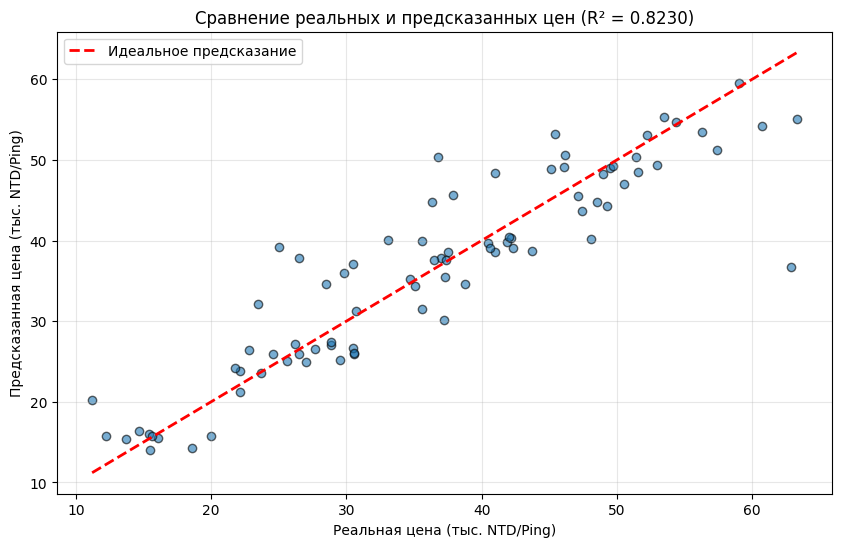

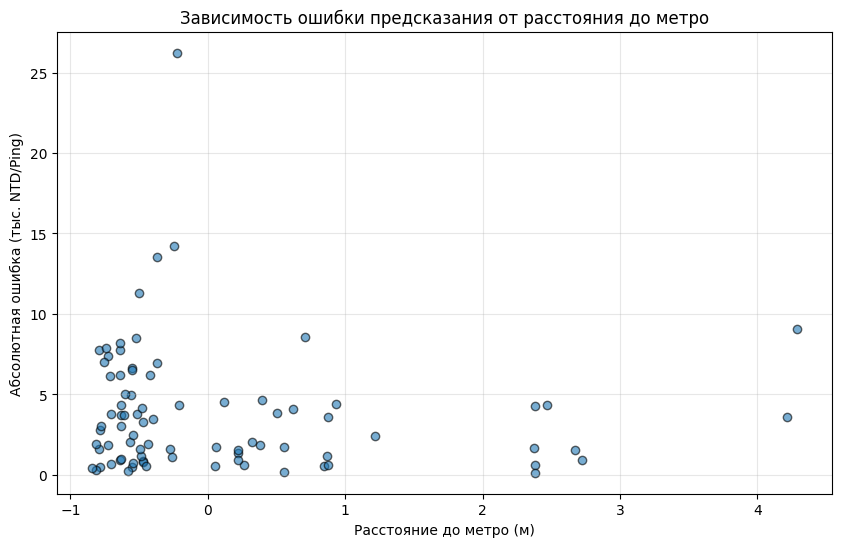

In [ ]:
y_pred_boxcox = best_rf.predict(X_test)
y_pred_original = (y_pred_boxcox * lambda_opt + 1) ** (1 / lambda_opt)
y_real_original = (y_test * lambda_opt + 1) ** (1 / lambda_opt)

y_pred_original = np.array(y_pred_original).flatten()
y_real_original = np.array(y_real_original).flatten()

rmse_test = sqrt(mean_squared_error(y_real_original, y_pred_original))
mae_test = mean_absolute_error(y_real_original, y_pred_original)
r2_test = r2_score(y_real_original, y_pred_original)

print(f"  R²  = {r2_test:.4f}")
print(f"  RMSE = {rmse_test:.2f} тыс. NTD/Ping")
print(f"  MAE  = {mae_test:.2f} тыс. NTD/Ping")

errors = np.abs(y_real_original - y_pred_original)

print(f"  Средняя ошибка: {errors.mean():.2f} тыс. NTD/Ping")
print(f"  Медианная ошибка: {np.median(errors):.2f} тыс. NTD/Ping")
print(f"  Стандартное отклонение ошибки: {errors.std():.2f}")
print(f"  Максимальная ошибка: {errors.max():.2f} тыс. NTD/Ping")
print(f"  Минимальная ошибка: {errors.min():.2f} тыс. NTD/Ping")

bins = [0, 1, 2, 3, 4, 5, 10, 20]
for i in range(len(bins)-1):
    count = np.sum((errors >= bins[i]) & (errors < bins[i+1]))
    print(f"  {bins[i]}-{bins[i+1]} тыс.: {count:2d} объектов ({count/len(errors)*100:.1f}%)")

top_errors = np.argsort(errors)[::-1][:10]
for i, idx in enumerate(top_errors, 1):
    real = y_real_original[idx]
    pred = y_pred_original[idx]
    error = errors[idx]
    dist = X_test.iloc[idx]['X3 distance to the nearest MRT station']
    age = X_test.iloc[idx]['X2 house age']
    stores = X_test.iloc[idx]['X4 number of convenience stores']
    print(f"  {i:2d}. Объект {idx}: цена реальная={real:.2f}, предсказанная={pred:.2f}, ошибка={error:.2f}")
    print(f" {dist:.0f}м, {age:.0f}лет, магазинов {stores:.0f}")

best_errors = np.argsort(errors)[:10]
for i, idx in enumerate(best_errors, 1):
    real = y_real_original[idx]
    pred = y_pred_original[idx]
    error = errors[idx]
    dist = X_test.iloc[idx]['X3 distance to the nearest MRT station']
    age = X_test.iloc[idx]['X2 house age']
    stores = X_test.iloc[idx]['X4 number of convenience stores']
    print(f"  {i:2d}. Объект {idx}: цена реальная={real:.2f}, предсказанная={pred:.2f}, ошибка={error:.2f}")
    print(f"      {dist:.0f}м, {age:.0f}лет, магазинов {stores:.0f}")
distances = X_test['X3 distance to the nearest MRT station'].values
dist_ranges = [(0, 300), (300, 600), (600, 1000), (1000, 2000), (2000, 5000)]

for d_min, d_max in dist_ranges:
    mask = (distances >= d_min) & (distances < d_max)
    if mask.sum() > 0:
        avg_real = y_real_original[mask].mean()
        avg_pred = y_pred_original[mask].mean()
        avg_error = errors[mask].mean()
        print(f"  Расстояние {d_min}-{d_max} м ({mask.sum():2d} объектов):")
        print(f"      средняя реальная цена {avg_real:.2f}, средняя предсказанная {avg_pred:.2f}, средняя ошибка = {avg_error:.2f}")
ages = X_test['X2 house age'].values
age_ranges = [(0, 10), (10, 20), (20, 30), (30, 50)]

for a_min, a_max in age_ranges:
    mask = (ages >= a_min) & (ages < a_max)
    if mask.sum() > 0:
        avg_real = y_real_original[mask].mean()
        avg_pred = y_pred_original[mask].mean()
        avg_error = errors[mask].mean()
        print(f"  Возраст {a_min}-{a_max} лет ({mask.sum():2d} объектов):")
        print(f"      средняя реальная цена {avg_real:.2f}, средняя предсказанная {avg_pred:.2f}, средняя ошибка = {avg_error:.2f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_real_original, y_pred_original, alpha=0.6, edgecolors='k')
plt.plot([y_real_original.min(), y_real_original.max()],
         [y_real_original.min(), y_real_original.max()], 'r--', lw=2, label='Идеальное предсказание')
plt.xlabel('Реальная цена (тыс. NTD/Ping)')
plt.ylabel('Предсказанная цена (тыс. NTD/Ping)')
plt.title(f'Сравнение реальных и предсказанных цен (R² = {r2_test:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(distances, errors, alpha=0.6, edgecolors='k')
plt.xlabel('Расстояние до метро (м)')
plt.ylabel('Абсолютная ошибка (тыс. NTD/Ping)')
plt.title('Зависимость ошибки предсказания от расстояния до метро')
plt.grid(True, alpha=0.3)
plt.show()